In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [8]:
np.random.seed(42)

data_size = 1000

sleep = np.random.randint(2, 9, data_size)
work_hours = np.random.randint(4, 16, data_size)
social_interaction = np.random.randint(0, 10, data_size)
physical_activity = np.random.randint(0, 10, data_size)
mood = np.random.randint(1, 10, data_size)
caffeine = np.random.randint(0, 6, data_size)
screen_time = np.random.randint(2, 14, data_size)
financial_pressure = np.random.randint(0, 10, data_size)
work_pressure = np.random.randint(0, 10, data_size)
relationship_stress = np.random.randint(0, 10, data_size)
anxiety_level = np.random.uniform(1, 10, 1000)

stress_percentage = (
    ((10 - sleep) / 10) * 15 +              # Less sleep → more stress
    (work_hours / 16) * 15 +                # Long work hours
    (screen_time / 14) * 10 +               # Screen fatigue
    (caffeine / 6) * 5 +                    # Caffeine impact
    (financial_pressure / 10) * 10 +        # Financial stress
    (work_pressure / 10) * 10 +             # Work stress
    (relationship_stress / 10) * 10 +       # Personal stress
    (anxiety_level / 10) * 10 +             # Anxiety contribution
    ((10 - social_interaction) / 10) * 7 +  # Less social life → stress
    ((10 - physical_activity) / 10) * 5 +   # Less exercise → stress
    ((10 - mood) / 10) * 3                  # Bad mood → stress
)

# Add controlled randomness
stress_percentage += np.random.normal(0, 5, size=data_size)

# Clip values
stress_percentage = np.clip(stress_percentage, 0, 100)

df = pd.DataFrame({
    "sleep": sleep,
    "work_hours": work_hours,
    "social_interaction": social_interaction,
    "physical_activity": physical_activity,
    "mood": mood,
    "caffeine": caffeine,
    "screen_time": screen_time,
    "financial_pressure": financial_pressure,
    "work_pressure": work_pressure,
    "relationship_stress": relationship_stress,
     "anxiety_level": anxiety_level,
    "stress_percentage": stress_percentage
})

df.to_csv("stress_dataset.csv", index=False)

df.head()

,sleep,work_hours,social_interaction,physical_activity,mood,caffeine,screen_time,financial_pressure,work_pressure,relationship_stress,anxiety_level,stress_percentage
0,8,10,2,3,6,1,6,5,9,7,2.893349,50.115322
1,5,13,0,7,9,3,10,1,8,2,1.207424,42.359945
2,6,6,8,6,5,2,8,4,7,7,9.070719,51.148580
3,8,4,7,4,4,5,8,5,4,5,2.896360,39.843492
4,4,8,1,9,5,2,7,4,5,5,3.047805,40.616334


In [9]:
X = df.drop("stress_percentage", axis=1)
y = df["stress_percentage"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))

R2 Score: 0.6004207955570606
Mean Absolute Error: 5.099850643990531


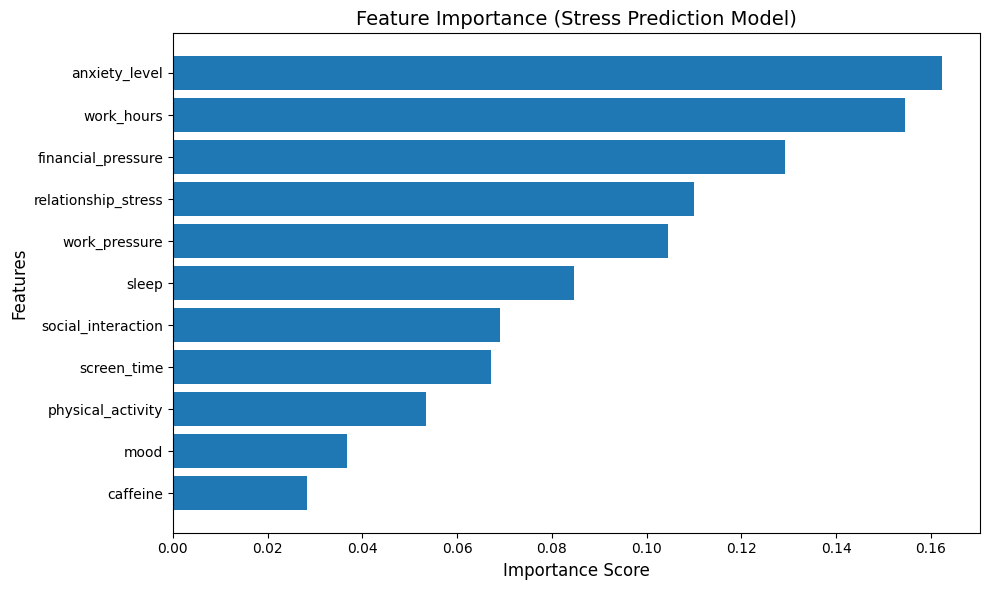

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance
importance = model.feature_importances_
features = X.columns

# Sort features for better visualization
sorted_idx = np.argsort(importance)
sorted_features = features[sorted_idx]
sorted_importance = importance[sorted_idx]

# Bigger figure
plt.figure(figsize=(10, 6))

# Horizontal bar chart (much clearer)
plt.barh(sorted_features, sorted_importance)

plt.title("Feature Importance (Stress Prediction Model)", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

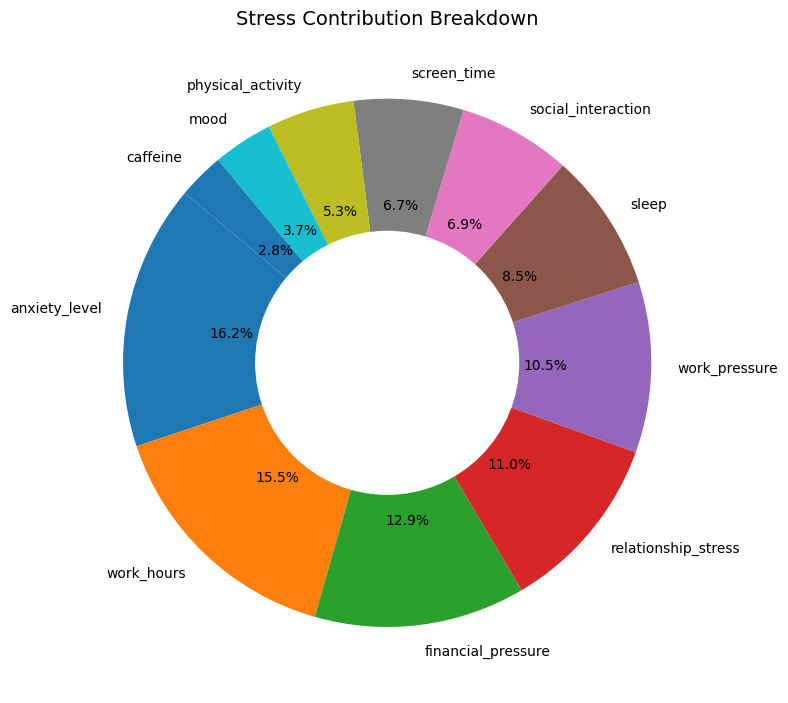

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance
importance = model.feature_importances_
features = X.columns

# Sort values
sorted_idx = np.argsort(importance)[::-1]
sorted_features = features[sorted_idx]
sorted_importance = importance[sorted_idx]

# Bigger figure
plt.figure(figsize=(8, 8))

# Donut chart (cleaner than normal pie)
wedges, texts, autotexts = plt.pie(
    sorted_importance,
    labels=sorted_features,
    autopct='%1.1f%%',
    startangle=140
)

# Draw circle in center for donut look
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Stress Contribution Breakdown", fontsize=14)
plt.tight_layout()
plt.show()

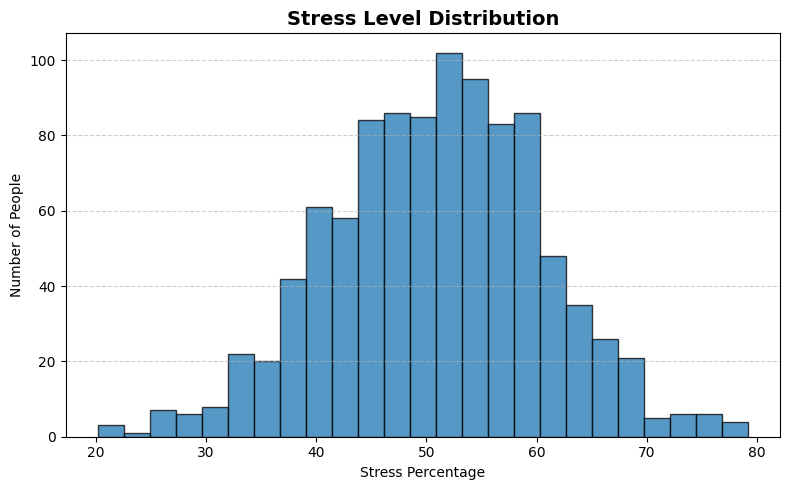

In [15]:
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(df["stress_percentage"], bins=25, edgecolor="black", alpha=0.75)

ax.set_title("Stress Level Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Stress Percentage")
ax.set_ylabel("Number of People")
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

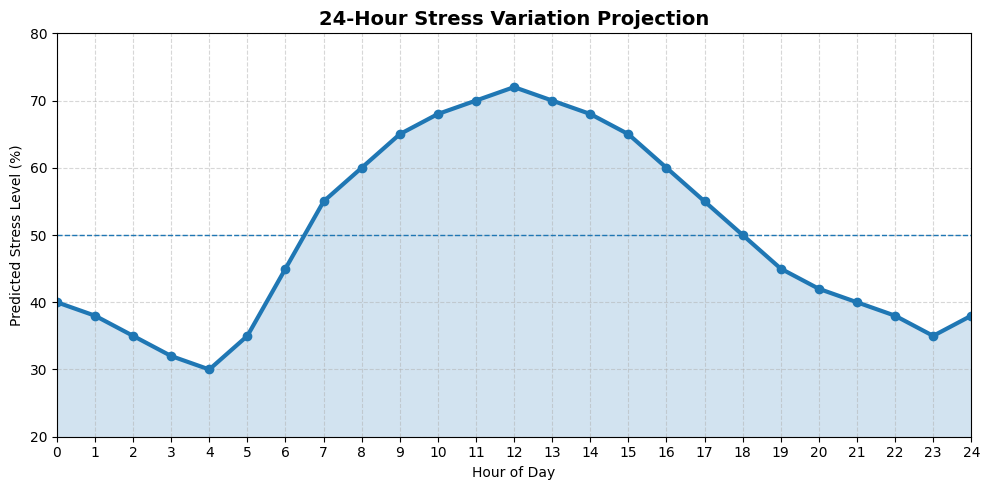

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Generate 0 to 24 hours (inclusive)
hours = np.arange(25)

base_stress = 50

# 25 values (important!)
daily_variation = np.array([
    base_stress - 10,
    base_stress - 12,
    base_stress - 15,
    base_stress - 18,
    base_stress - 20,
    base_stress - 15,
    base_stress - 5,
    base_stress + 5,
    base_stress + 10,
    base_stress + 15,
    base_stress + 18,
    base_stress + 20,
    base_stress + 22,
    base_stress + 20,
    base_stress + 18,
    base_stress + 15,
    base_stress + 10,
    base_stress + 5,
    base_stress,
    base_stress - 5,
    base_stress - 8,
    base_stress - 10,
    base_stress - 12,
    base_stress - 15,
    base_stress - 12   # hour 24
])

plt.figure(figsize=(10, 5))

plt.plot(hours, daily_variation, linewidth=3, marker="o")
plt.fill_between(hours, daily_variation, alpha=0.2)

plt.axhline(base_stress, linestyle="--", linewidth=1)

plt.title("24-Hour Stress Variation Projection", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Predicted Stress Level (%)")

plt.xticks(range(0, 25))
plt.xlim(0, 24)
plt.ylim(20, 80)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [21]:
def classify_stress(score):
    if score < 35:
        return "Low"
    elif score < 65:
        return "Moderate"
    else:
        return "High"

df["stress_category"] = df["stress_percentage"].apply(classify_stress)

df.head()

,sleep,work_hours,social_interaction,physical_activity,mood,caffeine,screen_time,financial_pressure,work_pressure,relationship_stress,anxiety_level,stress_percentage,stress_category
0,8,10,2,3,6,1,6,5,9,7,2.893349,50.115322,Moderate
1,5,13,0,7,9,3,10,1,8,2,1.207424,42.359945,Moderate
2,6,6,8,6,5,2,8,4,7,7,9.070719,51.148580,Moderate
3,8,4,7,4,4,5,8,5,4,5,2.896360,39.843492,Moderate
4,4,8,1,9,5,2,7,4,5,5,3.047805,40.616334,Moderate


In [22]:
def detect_causes(row):
    causes = []

    # 1. Sleep (lower = worse)
    if row["sleep"] < 5:
        causes.append("Severe Sleep Deprivation")
    elif row["sleep"] < 7:
        causes.append("Insufficient Sleep")

    # 2. Work Hours (higher = worse)
    if row["work_hours"] > 12:
        causes.append("Excessive Work Hours")
    elif row["work_hours"] > 9:
        causes.append("Long Work Hours")

    # 3. Social Interaction (lower = worse)
    if row["social_interaction"] < 3:
        causes.append("Social Isolation")
    elif row["social_interaction"] < 5:
        causes.append("Low Social Interaction")

    # 4. Physical Activity (lower = worse)
    if row["physical_activity"] < 3:
        causes.append("Very Low Physical Activity")
    elif row["physical_activity"] < 5:
        causes.append("Low Physical Activity")

    # 5. Mood (lower = worse)
    if row["mood"] < 3:
        causes.append("Very Poor Mood")
    elif row["mood"] < 5:
        causes.append("Low Mood")

    # 6. Caffeine (higher = worse)
    if row["caffeine"] > 4:
        causes.append("High Caffeine Intake")
    elif row["caffeine"] > 2:
        causes.append("Moderate Caffeine Intake")

    # 7. Screen Time (higher = worse)
    if row["screen_time"] > 12:
        causes.append("Excessive Screen Time")
    elif row["screen_time"] > 8:
        causes.append("High Screen Time")

    # 8. Financial Pressure (higher = worse)
    if row["financial_pressure"] > 7:
        causes.append("Severe Financial Stress")
    elif row["financial_pressure"] > 4:
        causes.append("Moderate Financial Stress")

    # 9. Work Pressure (higher = worse)
    if row["work_pressure"] > 7:
        causes.append("Severe Work Pressure")
    elif row["work_pressure"] > 4:
        causes.append("Moderate Work Pressure")

    # 10. Relationship Stress (higher = worse)
    if row["relationship_stress"] > 7:
        causes.append("Severe Relationship Stress")
    elif row["relationship_stress"] > 4:
        causes.append("Moderate Relationship Stress")

    # 11. Anxiety Level (VERY IMPORTANT)
    if row["anxiety_level"] > 8:
        causes.append("Extreme Anxiety Level")
    elif row["anxiety_level"] > 6:
        causes.append("High Anxiety Level")
    elif row["anxiety_level"] > 4:
        causes.append("Moderate Anxiety Level")

    return causes


df["stress_causes"] = df.apply(detect_causes, axis=1)

In [23]:
def generate_suggestions(causes):
    suggestions = []

    for cause in causes:

        if "Sleep" in cause:
            suggestions.append("Maintain a fixed sleep schedule and avoid screens before bed.")

        if "Work Hours" in cause:
            suggestions.append("Try time-blocking and prioritize important tasks to reduce overload.")

        if "Social" in cause:
            suggestions.append("Increase interaction with friends or family to improve emotional balance.")

        if "Physical Activity" in cause:
            suggestions.append("Incorporate at least 30 minutes of physical activity daily.")

        if "Mood" in cause:
            suggestions.append("Practice journaling or mindfulness meditation to regulate emotions.")

        if "Caffeine" in cause:
            suggestions.append("Reduce caffeine intake, especially after 4 PM.")

        if "Screen Time" in cause:
            suggestions.append("Limit non-essential screen usage and take digital detox breaks.")

        if "Financial" in cause:
            suggestions.append("Create a simple budget plan and track expenses weekly.")

        if "Work Pressure" in cause:
            suggestions.append("Discuss workload with supervisor or break tasks into smaller goals.")

        if "Relationship" in cause:
            suggestions.append("Communicate openly and consider resolving conflicts calmly.")

        if "Anxiety" in cause:
            suggestions.append("Practice deep breathing exercises and consider guided relaxation techniques.")

    # Remove duplicates
    suggestions = list(set(suggestions))

    return suggestions


df["ai_suggestions"] = df["stress_causes"].apply(generate_suggestions)

In [24]:
def classify_stress(level):

    if level < 35:
        return "Low Stress"

    elif 35 <= level < 70:
        return "Moderate Stress"

    else:
        return "High Stress"


df["stress_category"] = df["stress_percentage"].apply(classify_stress)

df.head()

,sleep,work_hours,social_interaction,physical_activity,mood,caffeine,screen_time,financial_pressure,work_pressure,relationship_stress,anxiety_level,stress_percentage,stress_category,stress_causes,ai_suggestions
0,8,10,2,3,6,1,6,5,9,7,2.893349,50.115322,Moderate Stress,"[Long Work Hours, Social Isolation, Low Physic...",[Incorporate at least 30 minutes of physical a...
1,5,13,0,7,9,3,10,1,8,2,1.207424,42.359945,Moderate Stress,"[Insufficient Sleep, Excessive Work Hours, Soc...",[Limit non-essential screen usage and take dig...
2,6,6,8,6,5,2,8,4,7,7,9.070719,51.148580,Moderate Stress,"[Insufficient Sleep, Moderate Work Pressure, M...",[Discuss workload with supervisor or break tas...
3,8,4,7,4,4,5,8,5,4,5,2.896360,39.843492,Moderate Stress,"[Low Physical Activity, Low Mood, High Caffein...","[Reduce caffeine intake, especially after 4 PM..."
4,4,8,1,9,5,2,7,4,5,5,3.047805,40.616334,Moderate Stress,"[Severe Sleep Deprivation, Social Isolation, M...",[Discuss workload with supervisor or break tas...


In [25]:
df.to_csv("stress_detection_dataset.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

# Feature columns
X = df[[
    "sleep",
    "work_hours",
    "social_interaction",
    "physical_activity",
    "mood",
    "caffeine",
    "screen_time",
    "financial_pressure",
    "work_pressure",
    "relationship_stress",
    "anxiety_level"
]]

# Target
y = df["stress_percentage"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestRegressor(n_estimators=200, random_state=42)

# Train
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "stress_model.pkl")

print("Model saved successfully as stress_model.pkl")

Model saved successfully as stress_model.pkl
